In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Gradient Penalties and Convergence

A well-defined adversarial objective does not guarantee that gradient training will converge. The preceding sections characterized equilibria in terms of divergences, critic classes, and pairing structures, but did not determine whether coupled parameter updates approach those equilibria. This section studies the Dirac-GAN, a minimal example consisting of two point masses and a linear critic. Its continuous-time dynamics orbit the solution indefinitely, while simultaneous discrete updates diverge for every positive step size. A zero-centered gradient penalty makes the equilibrium locally attracting for every positive penalty weight. Near equilibrium, the regularized game also measures a linearized optimal-transport distance. We then implement the loss from @Huang.Gokaslan.Kuleshov.ea.2024 and test it on a distribution with twenty-five modes.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

## Equilibrium Values Do Not Ensure Convergence

that section showed that the pairing objective removes the mode-dropping basins of the classical loss: its rank weight cannot be satisfied merely by placing generated samples beyond one decision threshold. Pairing does not, however, prevent saturation on disjoint supports. Its value is a Jensen--Shannon divergence of product measures, so it reaches its maximum when generated and data samples have disjoint supports. The resulting gradient is then zero. As that section showed, changing the classification loss changes the induced divergence but does not resolve support separation unless the objective also reflects the geometry of the sample space.

The best-response analysis also omits the dynamics used in training. Every derivation so far solved the critic's inner optimization exactly and then evaluated an outer objective. Actual training solves neither problem at each step. It updates two coupled players simultaneously or alternately, and each update changes the objective faced by the other player. An equilibrium calculation alone therefore provides no convergence guarantee. In the example below, gradient training fails even though the equilibrium is unique and the generator begins close to it.

The Dirac-GAN exhibits both support saturation and unstable training dynamics while remaining simple enough for an exact analysis. Its gradient flow circles the solution, and discretization turns these circles into outward spirals. Penalties on the critic's input gradient restore local convergence, with eigenvalues that can be computed explicitly. Near equilibrium, the penalized game measures a linearized Wasserstein-2 distance, connecting the regularizer to the transport geometry of that section. We conclude by combining the objective and penalties in the R3GAN recipe and measuring their effect on a twenty-five-mode distribution, with explicit limits on what the experiment establishes.

## The Dirac-GAN

Place the data at the origin and let the generator produce a single point on the real line: $p = \delta_0$ and $q_\theta = \delta_\theta$. The generator parameter $\theta$ is the position of its point mass, and $q = p$ exactly when $\theta = 0$. Let the critic be linear, $D_\psi(x) = \psi x$, with slope $\psi$. Under the margin objective the equation with function $\ell$, both expectations reduce to single evaluations:

$$
V(\theta, \psi) \;=\; \ell\big(D_\psi(0)\big) + \ell\big({-D_\psi(\theta)}\big)
\;=\; \ell(0) + \ell(-\psi\theta).
$$

This is the *Dirac-GAN* of @Mescheder.Geiger.Nowozin.2018 . The function $\ell$ may be any differentiable classification objective from that section with $\ell'(0) > 0$. We use the logistic choice $\ell = \log\sigma$ as the running example; it has derivative $\ell'(t) = \sigma(-t)$ and hence $\ell'(0) = \tfrac12$.

For any $\theta \neq 0$, the two point masses have disjoint supports. The critic's best response drives $\ell(-\psi\theta)$ toward its supremum by sending $\psi\theta \to -\infty$. Thus $\sup_\psi V = \ell(0) + \sup_t \ell(t)$ has the same value for every $\theta \neq 0$, although the supremum is approached rather than attained. Because this value is independent of $\theta$, it provides no generator gradient even arbitrarily close to the solution. This minimal example therefore reproduces the saturation analyzed in that section.

Actual training does not compute a best response at each iteration. Instead, both players take gradient steps from their current parameters. The game has a unique stationary point, $(\theta, \psi) = (0, 0)$, where the generated point matches the data and the critic is flat. In the simultaneous gradient descent--ascent flow, the generator descends $V$ and the critic ascends it:

$$
\dot\theta \;=\; -\partial_\theta V \;=\; \psi\, \ell'(-\psi\theta),
\qquad
\dot\psi \;=\; +\partial_\psi V \;=\; -\theta\, \ell'(-\psi\theta).
$$

The two components are the same positive scalar $\ell'(-\psi\theta)$ times the vector $(\psi, -\theta)$, which is orthogonal to the position $(\theta, \psi)$. The consequence is immediate:

$$
\frac{d}{dt}\big(\theta^2 + \psi^2\big)
= 2\theta\psi\,\ell'(-\psi\theta) - 2\psi\theta\,\ell'(-\psi\theta) = 0 .
$$

Every trajectory conserves its distance to the equilibrium, so the continuous-time dynamics move on exact circles for every objective in this family. The linearization at the origin gives the corresponding local result,

$$
J = \begin{pmatrix} 0 & \ell'(0) \\ -\ell'(0) & 0 \end{pmatrix},
\qquad
\lambda_{1,2} = \pm\, i\, \ell'(0):
$$

with purely imaginary eigenvalues. The equilibrium is a center rather than an attractor. Locally, the parameters rotate at angular speed $\ell'(0)$ and remain at constant distance from the equilibrium. The generator therefore passes the data point repeatedly without converging to it.

Discrete gradient steps are unstable even though the continuous flow preserves distance. A simultaneous step with size $\eta > 0$ applies the map $(\theta, \psi) \mapsto (\theta, \psi) + \eta\, v(\theta, \psi)$, where $v$ is the right-hand side of the equation. Since $v$ is orthogonal to $(\theta, \psi)$, the Pythagorean theorem gives

$$
\big\| (\theta, \psi) + \eta\, v \big\|^2
\;=\; \big\| (\theta, \psi) \big\|^2 + \eta^2 \big\| v \big\|^2 ,
$$

For the logistic objective, $\ell' > 0$ everywhere, so $v$ vanishes only at the equilibrium. Every step from any other point strictly increases the distance to the solution, regardless of the step size. A smaller $\eta$ only slows the outward spiral. Exercise 1 obtains the same conclusion from the update map's Jacobian, whose spectral radius $\sqrt{1 + \eta^2 \ell'(0)^2}$ exceeds one for every $\eta$. Alternating the two updates rather than taking them simultaneously also fails to restore convergence [@Mescheder.Geiger.Nowozin.2018].

Neither the non-saturating update nor the pairing objective changes these local dynamics. The non-saturating generator weight of the equation replaces $\ell'(-\psi\theta)$ by $\ell'(\psi\theta)$ in the first component of the field, leaving the Jacobian at the equilibrium unchanged. On this example, the pairing objective of that section reduces to $\ell\big(D_\psi(0) - D_\psi(\theta)\big) = \ell(-\psi\theta)$. It differs from the equation only by the constant $\ell(0)$ and therefore yields the same gradient field, circles, and outward spirals [@Huang.Gokaslan.Kuleshov.ea.2024]. Stabilization must therefore modify the two-player gradient dynamics themselves.

## Zero-Centered Penalties

Local linear attraction in the Dirac-GAN requires eigenvalues with negative real parts. The following regularizers on the critic supply this attraction. Define the two *zero-centered gradient penalties*

$$
R_1 \;=\; \frac{\gamma}{2}\, E_{x \sim p}\Big[ \big\| \nabla_x D(x) \big\|^2 \Big],
\qquad
R_2 \;=\; \frac{\gamma}{2}\, E_{x' \sim q}\Big[ \big\| \nabla_x D(x') \big\|^2 \Big],
$$

with weight $\gamma > 0$, and let the critic maximize $V_\ell(D) - R_1 - R_2$ while the generator's objective remains unchanged [@Roth.Lucchi.Nowozin.ea.2017; @Mescheder.Geiger.Nowozin.2018]. These penalties apply to the critic's *input* gradient rather than its parameter gradient. The term $R_1$ limits variation near data samples, and $R_2$ limits variation near generated samples. They are called zero-centered because both are minimized by the flat critic $\nabla_x D = 0$. At $q = p$, the optimal critic of that section is the constant $D^\star = \log(p/q) = 0$, so the penalties vanish at the equilibrium they are intended to stabilize. Since $\tfrac12(E_p + E_q) = E_m$, their sum is

$$
R_1 + R_2 \;=\; \gamma\, E_{x \sim m}\Big[ \big\| \nabla_x D(x) \big\|^2 \Big],
\qquad m = \frac{p + q}{2} :
$$

a single smoothness penalty under the balanced mixture that defines the log-loss game. It constrains critic variation in the regions sampled by either distribution.

### Damping the Dirac-GAN

For the Dirac-GAN, the linear critic has $\nabla_x D_\psi = \psi$ at every $x$, so both penalties reduce to $\tfrac{\gamma}{2}\psi^2$. Thus $R_1$ and $R_2$ are identical in this example, although they differ for general critics. Subtracting either penalty from the critic's objective adds $-\gamma\psi$ to the critic update. Using both doubles this term, which amounts to replacing $\gamma$ by $2\gamma$ in the following flow:

$$
\dot\theta = \psi\,\ell'(-\psi\theta),
\qquad
\dot\psi = -\theta\,\ell'(-\psi\theta) - \gamma\psi .
$$

The penalty changes the lower-right entry of the Jacobian:

$$
J_\gamma = \begin{pmatrix} 0 & \ell'(0) \\ -\ell'(0) & -\gamma \end{pmatrix},
\qquad
\lambda_{1,2} \;=\; -\frac{\gamma}{2} \pm \sqrt{ \frac{\gamma^2}{4} - \ell'(0)^2 } .
$$

Both eigenvalues have negative real parts for every $\gamma > 0$, so the equilibrium is attracting and gradient descent with a sufficiently small step size converges locally at a linear rate [@Mescheder.Geiger.Nowozin.2018]. The eigenvalues distinguish three damping regimes. When $\gamma < 2\ell'(0)$, the square root is imaginary and trajectories spiral inward. At $\gamma = 2\,|\ell'(0)|$, the repeated real eigenvalue gives critical damping, the fastest nonoscillatory approach; for the logistic objective this occurs at $\gamma = 1$. Larger values produce overdamped dynamics, whose convergence rate decreases as $\gamma$ grows. In Eq. 12 of @Huang.Gokaslan.Kuleshov.ea.2024, the expression under the root contains $\ell'(0)$ rather than $\ell'(0)^2$. This is a typographical error: the displayed Jacobian has determinant $\ell'(0)^2$, consistent with the original lemma of @Mescheder.Geiger.Nowozin.2018 .

### What the Penalized Game Measures

The damping analysis describes the local dynamics but not the quantity evaluated by the regularized game. That quantity has a closed form near equilibrium. In this regime the critic is close to the constant $D^\star = 0$, so we expand both objectives around $D \equiv 0$. The margin objective the equation and the pairing objective $\Phi$ from that section agree to first order up to additive constants:

$$
V_\ell(D) = 2\ell(0) + \ell'(0)\, \langle p - q,\, D \rangle + O(\|D\|^2),
\qquad
\Phi(D) = \ell(0) + \ell'(0)\, \langle p - q,\, D \rangle + O(\|D\|^2),
$$

where $\langle h, D\rangle = \int h(x)\, D(x)\, dx$, so $\langle p - q, D\rangle = E_p[D] - E_q[D]$. To leading order, every objective in the family therefore reduces to the same linear functional $a\,\langle p - q, D\rangle$, with $a = \ell'(0)$. The regularized critic maximizes this functional subject to a quadratic smoothness penalty, whose optimum has the following classical form.

**Proposition.** *For $a \in \mathbb{R}$ and $\gamma > 0$,*

$$
\sup_{D} \Big\{ a\, \langle p - q,\, D \rangle \;-\; \gamma \int m\, \| \nabla_x D \|^2 \Big\}
\;=\; \frac{a^2}{4\gamma}\, \big\| p - q \big\|^2_{\dot H^{-1}(m)},
$$

*where the dual Sobolev norm is $\|h\|_{\dot H^{-1}(m)} = \sup\big\{ \langle h, D\rangle : \int m \|\nabla_x D\|^2 \leq 1 \big\}$, and the maximizing critic solves the weighted Poisson equation $a\,(p - q) + 2\gamma\, \nabla \cdot (m\, \nabla_x D) = 0$.*

Constants do not enter, since $\int (p - q) = 0$ and a constant critic has zero gradient; the supremum is over critics modulo constants. The computation behind the statement is one-dimensional: along each ray $\{t D_0\}$ the objective is a scalar quadratic in $t$, and optimizing over the direction $D_0$ produces the squared dual norm. Exercise 3 carries it out.

Equation the equation is a squared norm of the *difference* $p - q$, whereas the unpenalized objectives in this chapter depend on the *ratio* $p/q$. The ratio degenerates when the supports separate, but a norm of the difference can continue to vary as the supports move. The value scales as $1/\gamma$. Its local weighting is determined by the mixture $m$, which penalizes critic variation where either distribution has mass but not outside their combined support.

The norm also has a geometric interpretation. Equation the equation defines the Wasserstein-2 distance as the minimum quadratic transport cost between two distributions. The Benamou--Brenier theorem the equation expresses the same distance as the least kinetic energy of a flow that transports one distribution into the other.

In this dynamic formulation, an infinitesimal perturbation $h$ of a base distribution $m$ is carried by a velocity field $\nabla\phi$ satisfying the continuity equation $h + \nabla \cdot (m\, \nabla\phi) = 0$. This is the same Poisson equation solved by the optimal penalized critic, and the kinetic energy of the field is $\|h\|^2_{\dot H^{-1}(m)}$. Consequently,

$$
W_2(m,\, m + \epsilon h)
= \epsilon\, \|h\|_{\dot H^{-1}(m)} + o(\epsilon).
$$

The dual Sobolev norm is therefore the local metric of optimal transport. Near equilibrium, the penalized adversarial game measures the squared linearized $W_2$ distance between $p$ and $q$, scaled by $a^2/(4\gamma)$ to leading order. It obtains this transport geometry from two expectations of a squared gradient, without imposing a Lipschitz constraint. This interpretation restates the local convergence results of @Mescheder.Geiger.Nowozin.2018 and @Huang.Gokaslan.Kuleshov.ea.2024 without computing a Jacobian.

The conclusion has two important qualifications. It is local because it relies on linearization about a constant critic. It is also formal because it assumes that $m$ has a density and that the Poisson equation is solvable; we do not verify those conditions here. The next section considers the penalty away from equilibrium.

### One-Centered versus Zero-Centered

WGAN-GP uses a different center [@Gulrajani.Ahmed.Arjovsky.ea.2017]. To enforce the Lipschitz constraint from that section, it penalizes $E\big[(\|\nabla_x D\| - 1)^2\big]$ at points interpolated between real and generated samples. This *one-centered* penalty is motivated by optimal $W_1$ potentials, which have unit slope along transport rays. At $q = p$, however, the optimal critic is constant. The zero-centered penalty is minimized by this critic, whereas the one-centered penalty favors a unit input-gradient norm. The WGAN-GP critic can therefore retain a nonzero gradient at equilibrium and continue to update a generator that already matches the data. On the Dirac-GAN, the resulting dynamics do not converge to the equilibrium [@Mescheder.Geiger.Nowozin.2018].

| penalty | at $q = p$ | induced geometry | Dirac-GAN test |
|:---|:---|:---|:---|
| one-centered, $E\big[(\|\nabla_x D\| - 1)^2\big]$ | rewards unit slope | $W_1$ | does not converge |
| zero-centered, $E_m\big[\|\nabla_x D\|^2\big]$ | rewards the flat critic | linearized $W_2$ | converges for every $\gamma > 0$ |

### Phase Portraits

The predicted circular, divergent, and contracting trajectories can be checked by simulating the two coupled scalar equations. For the logistic objective, $\ell'(-\psi\theta) = \sigma(\psi\theta)$ gives the field in the equation directly. The first panel integrates the continuous flow with small fourth-order Runge--Kutta steps. The second applies simultaneous gradient steps and includes the flow's conserved circle as a dashed reference. The third adds the penalty at $\gamma = 0.3$, which gives complex eigenvalues, and at $\gamma = 1$, which gives critical damping for the logistic objective. All three trajectories begin at $(\theta, \psi) = (1, 1)$, marked in red; the cross marks the equilibrium.

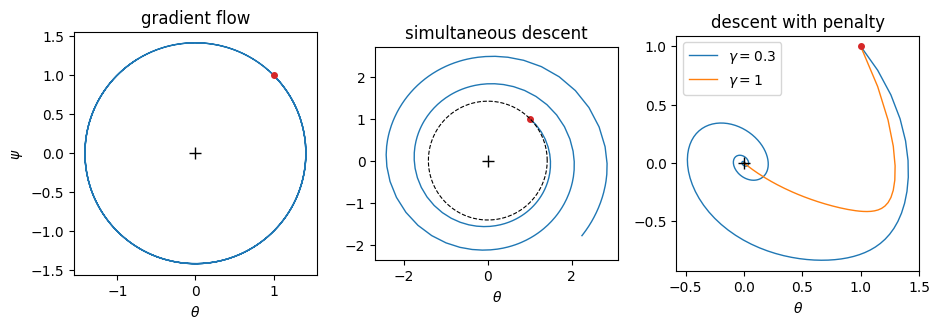

In [2]:
def dirac_field(theta, psi, gamma=0.0):
    """Simultaneous gradient field of the Dirac-GAN with logistic payoff."""
    s = 1.0 / (1.0 + np.exp(-psi * theta))       # l'(-psi * theta)
    return np.array([psi * s, -theta * s - gamma * psi])

def trajectory(x0, eta, steps, gamma=0.0, flow=False):
    xs, x = [np.array(x0)], np.array(x0)
    for _ in range(steps):
        if flow:                                  # one RK4 step of the ODE
            k1 = dirac_field(*x, gamma)
            k2 = dirac_field(*(x + eta / 2 * k1), gamma)
            k3 = dirac_field(*(x + eta / 2 * k2), gamma)
            k4 = dirac_field(*(x + eta * k3), gamma)
            x = x + eta / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        else:                                     # one simultaneous GD step
            x = x + eta * dirac_field(*x, gamma)
        xs.append(x)
    return np.stack(xs)

x0 = (1.0, 1.0)
panels = [('gradient flow', [('', trajectory(x0, 0.05, 800, flow=True))]),
          ('simultaneous descent', [('', trajectory(x0, 0.2, 300))]),
          ('descent with penalty',
           [('$\\gamma = 0.3$', trajectory(x0, 0.2, 300, gamma=0.3)),
            ('$\\gamma = 1$', trajectory(x0, 0.2, 300, gamma=1.0))])]
fig, axes = d2l.plt.subplots(1, 3, figsize=(9.5, 3.2))
for ax, (title, paths) in zip(axes, panels):
    for label, path in paths:
        ax.plot(path[:, 0], path[:, 1], lw=1, label=label or None)
    ax.plot(*x0, 'o', ms=4, c='C3')
    ax.plot(0, 0, 'k+', ms=8)
    ax.set_title(title)
    ax.set_xlabel(r'$\theta$')
    ax.set_aspect('equal')
    if len(paths) > 1:
        ax.legend()
axes[0].set_ylabel(r'$\psi$')
t = np.linspace(0, 2 * np.pi, 200)
axes[1].plot(np.sqrt(2) * np.cos(t), np.sqrt(2) * np.sin(t), 'k--', lw=0.8)
fig.tight_layout()

The phase portraits agree with the eigenvalue analysis. To visual accuracy, the integrated flow repeatedly traces the same circle, as required by the conservation law. The discrete iterates leave the dashed circle immediately and cross their previous orbit on every revolution; after 300 steps their distance from the equilibrium is twice its initial value. Both penalized trajectories converge. The underdamped trajectory follows a shrinking spiral, whereas the critically damped trajectory turns once before approaching without further rotation. The penalty changes the dynamics from divergence to convergence without changing the equilibrium of the objective.

## When One Penalty Is Not Enough

The Dirac-GAN cannot distinguish $R_1$ from $R_2$ because the linear critic has the same slope everywhere. More generally, either penalty can suffice near equilibrium. When the supports of $p$ and $q$ nearly coincide, regularizing the critic under one measure also controls it under the other, and the equation holds with $m$ replaced by either measure. The local convergence result of @Mescheder.Geiger.Nowozin.2018 therefore requires only one penalty.

Far from equilibrium, the two penalties are no longer interchangeable. The interpretation of @Roth.Lucchi.Nowozin.ea.2017 explains why. Up to a weighting factor and a higher-order error term, penalizing $E_p\big[\|\nabla_x D\|^2\big]$ modifies the game like convolving $p$ with Gaussian noise whose covariance is proportional to $\gamma$; $R_2$ similarly smooths $q$. Smoothing two mutually singular distributions makes their densities overlap, rendering their density ratio finite and the divergence sensitive to the distance between their supports. The penalties produce this effect analytically without perturbing the samples. This argument requires both distributions to be smoothed. With $R_1$ alone, the critic is unconstrained in regions containing generated but not real samples. @Huang.Gokaslan.Kuleshov.ea.2024 observe the corresponding behavior: the critic's input gradients on generated samples grow without bound and training diverges.

The available evidence is empirical and depends on the training setting. In R3GAN's StackedMNIST ablation, training with $R_1$ alone diverged early for both the classical and pairing objectives. Increasing $\gamma$ from 0.1 to 100 did not prevent divergence, whereas adding $R_2$ restored convergence in every tested case [@Huang.Gokaslan.Kuleshov.ea.2024]. StyleGAN2 provides an important counterexample: it trained successfully on FFHQ using $R_1$ alone [@Karras.Laine.Aittala.ea.2020]. Whether one penalty suffices therefore depends on the dataset and the remaining training choices. Both the smoothing argument and the R3GAN ablation favor symmetric regularization, at the cost of one additional term in the backward pass.

## The R3GAN Recipe

The preceding results combine into a practical objective. R3GAN uses the pairing loss of that section, trains the generator with its non-saturating form, and subtracts both zero-centered penalties from the critic's objective. Pairing addresses mode-dropping minima in the best-response landscape, while the penalties make the equilibrium locally attracting. @Huang.Gokaslan.Kuleshov.ea.2024 show that this loss supports a comparatively simple architecture without many of the specialized components used by earlier GANs.

### The Loss in Code

The implementation separates the critic loss, generator loss, and gradient penalties. For a real sample $x$ and generated sample $y$, the critic minimizes the pairing loss $\mathrm{softplus}(D(y) - D(x)) = -\log \sigma(D(x) - D(y))$, averaged over aligned pairs in the two batches. The generator reverses the ranking and minimizes $\mathrm{softplus}(D(x) - D(y))$. This is the non-saturating update used by the reference implementation, rather than the zero-sum form displayed in the paper, as discussed in that section. The penalty function returns unscaled per-sample squared gradient norms for both distributions. The caller applies the batch mean and the factor $\gamma/2$, allowing the same function to implement either penalty alone or their sum.

The two implementations differ only in their use of automatic differentiation. In PyTorch, one backward pass through the *sum* of the critic outputs produces the input gradient for every sample. This gradient decomposes by row because each output depends only on the corresponding input row; the property requires a critic without batch-mixing layers such as batch normalization. Setting `create_graph=True` retains the graph needed to differentiate the penalty with respect to the critic parameters.

In JAX, a per-sample `grad` computes the input gradient and `vmap` applies it across the batch. Nested functional differentiation supplies the required second derivative without an additional flag. Both implementations first detach the samples, using `detach` in PyTorch and `stop_gradient` in JAX. Consequently, the penalty updates the critic parameters but not the process that generated the samples.

In [3]:

def rpgan_loss_D(critic, real, fake):
    """Relativistic pairing loss for the critic: -E[log sigma(D(x) - D(y))]."""
    return F.softplus(critic(fake) - critic(real)).mean()


def rpgan_loss_G(critic, real, fake):
    """Non-saturating pairing loss for the generator."""
    return F.softplus(critic(real) - critic(fake)).mean()


def r1_r2_penalty(critic, real, fake):
    """Per-sample squared critic input gradients on real (R1) and fake (R2),
    before the gamma/2 scale."""
    def sq_grad_norm(x):
        x = x.detach().requires_grad_(True)
        grad, = torch.autograd.grad(critic(x).sum(), x, create_graph=True)
        return grad.reshape(x.shape[0], -1).pow(2).sum(dim=1)
    return sq_grad_norm(real), sq_grad_norm(fake)

The penalties are evaluated at every critic step. StyleGAN2 instead uses *lazy regularization*: it applies the penalty only every few minibatches and rescales it to compensate. In the R3GAN ablation, this schedule slightly reduced image quality on real datasets and caused training to fail on StackedMNIST and two-dimensional toy problems [@Huang.Gokaslan.Kuleshov.ea.2024].

### Principles and Evidence

R3GAN summarizes its ablations as six training principles. The first is a convergent objective: the paper emphasizes $R_1$, while the implemented recipe uses the pairing loss with both $R_1$ and $R_2$, as in this section. The remaining principles specify (b) a small learning rate and Adam with no first-moment momentum ($\beta_1 = 0$); (c) no normalization layers in either network; (d) bilinear interpolation rather than strided or transposed convolution for resampling; (e) leaky ReLU in both networks and no tanh at the generator output; and (f) a modern residual backbone. Their ablations report that violating (a), (b), or (c) often prevents training, whereas changing (d) or (e) mainly reduces sample quality [@Huang.Gokaslan.Kuleshov.ea.2024]. An experiment on FFHQ-256 tests whether these principles can replace the specialized components of StyleGAN2 while approximately matching parameter count and training budget:

| config | change relative to the previous row | FID |
|:---|:---|---:|
| A | StyleGAN2 baseline | 7.5 |
| B | remove all ten tricks: $z$ normalization, minibatch standard deviation, equalized learning rate, mapping network, style injection, weight demodulation, noise injection, mixing regularization, path-length regularization, lazy regularization | 12.5 |
| C | add the well-behaved loss: RpGAN objective with $R_1$ and $R_2$ | 11.7 |
| D | modernize the backbone: ResNet generator and critic | 10.0 |
| E | widen with grouped convolutions and inverted bottlenecks | 7.0 |

Removing the ten components raises FID from 7.5 to 12.5. Adding the revised loss and modernizing the architecture lowers it to 7.0, slightly below the StyleGAN2 baseline despite retaining none of the removed components [@Huang.Gokaslan.Kuleshov.ea.2024]. A separate loss ablation uses StackedMNIST, which combines MNIST digits into a synthetic distribution with 1000 known modes [@Metz.Poole.Pfau.ea.2017], to distinguish the effects of pairing and gradient penalties:

| loss | modes recovered (of 1000) | reverse KL |
|:---|---:|---:|
| RpGAN with $R_1$ and $R_2$ | 1000 | 0.078 |
| GAN with $R_1$ and $R_2$ | 693 | 0.927 |
| RpGAN with $R_1$ only | diverged | --- |
| GAN with $R_1$ only | diverged | --- |

Under identical penalties, the classical loss recovers 693 modes with reverse KL 0.927, whereas the pairing loss recovers all 1000 modes with reverse KL 0.078. Without $R_2$, both objectives diverge for every tested value of $\gamma$ [@Huang.Gokaslan.Kuleshov.ea.2024]. These single runs on one synthetic dataset suggest that the penalties govern convergence while pairing improves coverage; they do not establish the magnitude of either effect more broadly.

The reported hyperparameters and compute also delimit these results. Across R3GAN's benchmarks, $\gamma$ ranges from 0.05 on CIFAR-10 to 150 on FFHQ-256, so a value tuned on one problem provides only an order-of-magnitude starting point for another. The quoted experiments require seven hours on eight L40 GPUs for StackedMNIST, four days for CIFAR-10, about three weeks on eight A6000s for FFHQ-256, and about a day on 32 H100s for conditional ImageNet [@Huang.Gokaslan.Kuleshov.ea.2024]. The experiment below runs in minutes; that section discusses image-scale training.

### Mode Coverage on 25 Gaussians

The final experiment examines the penalties on a small multimodal distribution. The target is a mixture of 25 Gaussians arranged on a $5 \times 5$ grid, with spacing 2 and standard deviation $\sigma = 0.05$. Because the spacing is large relative to the mode width, we count a mode as covered when at least one of 10,000 generated samples falls within $3\sigma$ of its center. We compare three configurations with identical networks and optimization settings: the non-saturating GAN of that section without a penalty, the same objective with $R_1 + R_2$, and RpGAN with $R_1 + R_2$. The generator maps a 64-dimensional latent vector through two hidden layers of 256 units. The critic uses the same hidden width, leaky ReLU activations, and no normalization layers. Both networks use Adam with $\beta_1 = 0$, $\beta_2 = 0.99$, learning rate $2 \cdot 10^{-4}$, and batch size 256 for 20,000 generator steps. Penalized configurations use $\gamma = 1$.

In [4]:
device = d2l.try_gpu()

def grid_centers(side=5, spacing=2.0):
    coords = (torch.arange(side, dtype=torch.float32) - (side - 1) / 2) * spacing
    gx, gy = torch.meshgrid(coords, coords, indexing='ij')
    return torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1)

def sample_modes(centers, n, std=0.05):
    idx = torch.randint(0, centers.shape[0], (n,), device=centers.device)
    return centers[idx] + std * torch.randn(n, 2, device=centers.device)

centers = grid_centers().to(device)

def gan_loss_D(critic, real, fake):
    return (F.softplus(-critic(real)) + F.softplus(critic(fake))).mean()

def gan_loss_G(critic, fake):
    return F.softplus(-critic(fake)).mean()

def make_mlp(sizes, act):
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i + 1]))
        if i < len(sizes) - 2:
            layers.append(act())
    return nn.Sequential(*layers)

def train_toy(loss_type, gamma, steps=20000, batch=256, latent=64):
    torch.manual_seed(2)
    net_G = make_mlp([latent, 256, 256, 2], nn.ReLU).to(device)
    net_D = make_mlp([2, 256, 256, 1],
                     lambda: nn.LeakyReLU(0.2)).to(device)
    opt_G = torch.optim.Adam(net_G.parameters(), lr=2e-4, betas=(0.0, 0.99))
    opt_D = torch.optim.Adam(net_D.parameters(), lr=2e-4, betas=(0.0, 0.99))
    for _ in range(steps):
        real = sample_modes(centers, batch)
        with torch.no_grad():
            fake = net_G(torch.randn(batch, latent, device=device))
        if loss_type == 'rp':
            loss_D = rpgan_loss_D(net_D, real, fake)
        else:
            loss_D = gan_loss_D(net_D, real, fake)
        if gamma > 0:
            r1, r2 = r1_r2_penalty(net_D, real, fake)
            loss_D = loss_D + gamma / 2 * (r1 + r2).mean()
        opt_D.zero_grad(), loss_D.backward(), opt_D.step()
        fake = net_G(torch.randn(batch, latent, device=device))
        if loss_type == 'rp':
            loss_G = rpgan_loss_G(net_D, sample_modes(centers, batch), fake)
        else:
            loss_G = gan_loss_G(net_D, fake)
        opt_G.zero_grad(), loss_G.backward(), opt_G.step()
    return net_G

configs = [('GAN', 'gan', 0.0), ('GAN + $R_1 + R_2$', 'gan', 1.0),
           ('RpGAN + $R_1 + R_2$', 'rp', 1.0)]
generators = {name: train_toy(loss_type, gamma)
              for name, loss_type, gamma in configs}

We draw 10,000 samples from each trained generator and measure both coverage and fit. For coverage, each sample within $3\sigma$ of a center is assigned to its nearest mode. We report the number of modes represented and the reverse KL divergence between the resulting 25-way histogram and the uniform distribution. For fit, we report the fraction of samples within these neighborhoods, its complement as off-mode mass, and the mean and median distance to the nearest center. We also compute a reverse KL divergence on 26 bins: one for each mode and one for all off-mode samples. A two-dimensional Gaussian places $1 - e^{-9/2} \approx 0.989$ of its mass within $3\sigma$ of its center. The target histogram therefore assigns $0.989/25$ to each mode and $0.011$ to the off-mode bin; a generator that matches the mixture has zero KL under this discretization.

GAN: 21/25 modes, reverse KL 0.91, on-mode fraction 0.06
    off-mode mass 0.94, nearest-center distance mean 0.68 / median 0.68, 26-bin KL 4.06
GAN + $R_1 + R_2$: 25/25 modes, reverse KL 0.51, on-mode fraction 0.10
    off-mode mass 0.90, nearest-center distance mean 0.59 / median 0.59, 26-bin KL 3.78
RpGAN + $R_1 + R_2$: 25/25 modes, reverse KL 0.48, on-mode fraction 0.09
    off-mode mass 0.91, nearest-center distance mean 0.61 / median 0.62, 26-bin KL 3.85


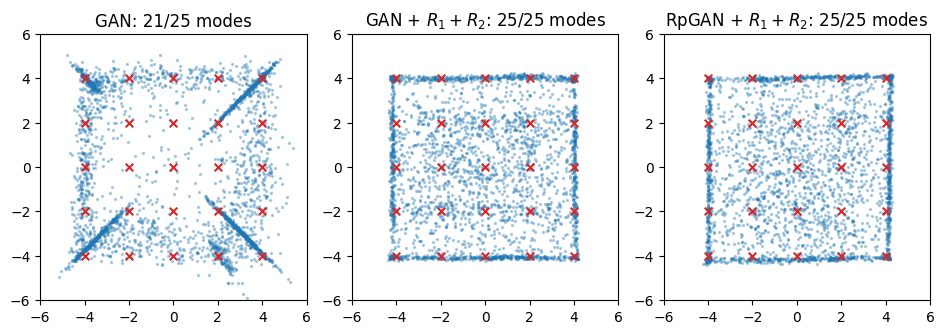

In [5]:
def mode_coverage(net_G, n=10000, latent=64, std=0.05):
    torch.manual_seed(1)
    with torch.no_grad():
        x = net_G(torch.randn(n, latent, device=device))
    near, idx = torch.cdist(x, centers).min(dim=1)
    on = near <= 3 * std
    counts = torch.bincount(idx[on], minlength=len(centers)).float().cpu()
    share = counts[counts > 0] / counts.sum()
    rev_kl = float((share * (share * len(centers)).log()).sum())
    on_mass = 1 - np.exp(-4.5)             # P(|x - c| <= 3 sigma) in 2d
    p = torch.cat([torch.full((25,), on_mass / 25),
                   torch.tensor([1 - on_mass])])
    q = torch.cat([counts, (n - counts.sum()).reshape(1)]) / n
    kl26 = float((q[q > 0] * (q[q > 0] / p[q > 0]).log()).sum())
    stats = dict(covered=int((counts > 0).sum()), rev_kl=rev_kl,
                 on_frac=float(on.float().mean()), d_mean=float(near.mean()),
                 d_med=float(near.median()), kl26=kl26)
    return x.cpu(), stats

fig, axes = d2l.plt.subplots(1, 3, figsize=(9.5, 3.4))
for ax, (name, _, _) in zip(axes, configs):
    x, s = mode_coverage(generators[name])
    ax.scatter(x[:3000, 0], x[:3000, 1], s=2, alpha=0.3)
    ax.scatter(centers.cpu()[:, 0], centers.cpu()[:, 1], marker='x', s=30,
               c='C3')
    ax.set_title(f"{name}: {s['covered']}/25 modes")
    ax.set_xlim(-6, 6), ax.set_ylim(-6, 6)
    ax.set_aspect('equal')
    print(f"{name}: {s['covered']}/25 modes, reverse KL {s['rev_kl']:.2f}, "
          f"on-mode fraction {s['on_frac']:.2f}")
    print(f"    off-mode mass {1 - s['on_frac']:.2f}, nearest-center "
          f"distance mean {s['d_mean']:.2f} / median {s['d_med']:.2f}, "
          f"26-bin KL {s['kl26']:.2f}")
fig.tight_layout()

The displayed runs support a comparison between the unpenalized configuration and the two penalized ones. The plain non-saturating GAN trains without divergence or exploding losses in this experiment, but it does not cover all 25 modes. Its reverse KL is also substantially higher because samples concentrate in filaments and clusters while some centers receive none. Both penalized configurations cover all 25 modes and distribute the samples among those modes more evenly.

Coverage does not imply that the generated distribution matches the mixture. The target assigns 98.9% of its mass to the $3\sigma$ neighborhoods, but each trained generator places only about one tenth or less of its mass there in the stored runs. The mean and median nearest-center distances are several times the target standard deviation $\sigma = 0.05$, indicating that the generated clusters are much wider than the target modes. Consequently, the off-mode bin dominates the 26-bin KL. The experiment shows that the penalties improve support reach and balance, but none of the three configurations closely fits the target distribution at this model size and training budget.

The experiment does not distinguish the two penalized configurations because both attain the maximum coverage score on 25 well-separated modes. The reported advantage of pairing appears under greater capacity pressure in StackedMNIST: RpGAN covers 1000 of 1000 modes with reverse KL 0.078, compared with 693 modes and reverse KL 0.927 for the classical loss under the same penalties [@Huang.Gokaslan.Kuleshov.ea.2024]. The two-dimensional experiment has neither enough modes nor a sufficiently constrained generator to reproduce this difference. It supports only the narrower conclusion that the penalties improve coverage and balance in this setting. Evidence for the additional effect of pairing comes from StackedMNIST. Exercise 4 asks how the reported coverage and fit statistics can differ so sharply.

## Summary

An equilibrium analysis does not imply that gradient training will reach the equilibrium. On the Dirac-GAN, the simultaneous gradient field is orthogonal to the parameter vector. Continuous-time trajectories therefore move on circles with eigenvalues $\pm i\,\ell'(0)$, while simultaneous discrete updates increase the distance to the solution at every positive step size. Neither the non-saturating generator weighting nor the pairing objective changes this local field.

The zero-centered penalties $R_1$ and $R_2$ add damping through $\gamma E_m[\|\nabla_xD\|^2]$. Their eigenvalues $-\gamma/2 \pm \sqrt{\gamma^2/4-\ell'(0)^2}$ have negative real part for every $\gamma>0$, with critical damping at $\gamma=2|\ell'(0)|$. Near equilibrium, the penalized game evaluates $\tfrac{a^2}{4\gamma}\|p-q\|^2_{\dot H^{-1}(m)}$, the squared linearized Wasserstein-2 distance. Unlike a density ratio, this difference-based quantity remains meaningful as nearby supports move. The one-centered WGAN-GP penalty does not have the same equilibrium behavior.

Far from equilibrium, the two penalties smooth the data and generator distributions in complementary regions, so one penalty may be insufficient. R3GAN's StackedMNIST ablation attributes convergence to the pair of penalties and improved mode coverage to the relativistic objective. The 25-Gaussians experiment confirms the effect on reach and balance at small scale: both penalized runs cover every mode more evenly than the unpenalized run. All configurations nevertheless place most of their mass outside the narrow target modes, so this experiment demonstrates coverage rather than a close distributional fit. The additional benefit of pairing requires the larger StackedMNIST comparison. that section applies the combined loss to images.

## Exercises

1. The discrete simultaneous update of the Dirac-GAN with step size $\eta > 0$ is the map $(\theta, \psi) \mapsto \big(\theta + \eta\,\psi\,\ell'(-\psi\theta),\; \psi - \eta\,\theta\,\ell'(-\psi\theta)\big)$. Compute the Jacobian of this map at the equilibrium $(0, 0)$ and show that its eigenvalues are $1 \pm i\,\eta\,\ell'(0)$, so the spectral radius is $\sqrt{1 + \eta^2\,\ell'(0)^2} > 1$ for every step size. Conclude that no choice of $\eta$ makes the unpenalized game locally convergent. The norm identity in the text shows this growth exactly, at every point of the plane; the eigenvalue computation here recovers the same conclusion in linearized form at the equilibrium.
1. Derive the equation from the equation. Then explain why the mixture weighting matters: construct a critic and a pair of distributions with separated supports for which $E_p\big[\|\nabla_x D\|^2\big] = 0$ while $E_q\big[\|\nabla_x D\|^2\big]$ is arbitrarily large, and relate your construction to the failure of $R_1$-only training described in the text.
1. Prove the equation. Restrict the objective to a ray $\{t D_0 : t \in \mathbb{R}\}$ with $\int m\,\|\nabla_x D_0\|^2 = 1$, maximize the resulting scalar quadratic in $t$, and then take the supremum over directions $D_0$. Verify from the result that the value of the penalized game is proportional to $1/\gamma$, so that doubling the penalty weight halves the value at every fixed pair $(p, q)$.
1. The printed statistics of the mode-coverage experiment appear to conflict: a penalized run covers 25 of 25 modes, yet only a small fraction of its mass lies within $3\sigma$ of any center. (a) Explain how both can be true at once, given that coverage is a threshold statistic over 10,000 samples. (b) From the printed on-mode fraction, compute the off-mode bin's contribution $q_{\textrm{off}} \log(q_{\textrm{off}} / 0.011)$ to the 26-bin KL and compare it with the printed total: how much of the divergence is the off-mode mass alone? (c) Two arrangements are consistent with a small on-mode fraction: per-mode clouds centered on the modes but wider than the target's $\sigma = 0.05$, and mass strewn along paths between modes. Which statistics of the nearest-center distance distribution, beyond the printed mean and median, would distinguish them, and what would each arrangement predict? (d) Without re-running anything, predict from the damping regimes of the equation which failure each direction of the penalty weight invites: $\gamma = 10$ versus $\gamma = 0.1$.
1. In the middle panel of the phase portrait, sweep the step size over $\eta \in \{0.01, 0.05, 0.2, 0.5\}$ with $\gamma = 0$. Does any step size stabilize the unpenalized game, or change anything other than the rate at which the spiral grows? Reconcile the observation with Exercise 1.

[Discussions](https://d2l.discourse.group/)